# Defenses Against Adversarial Attacks on CNNs
## From Preprocessing Heuristics to Certified Guarantees

*Part 3 of the AI Security Series by **Camilo Pestana, PhD***

---

## Overview

| # | Defense | Strength | Computational Cost | Certification |
|---|---------|----------|--------------------|---------------|
| 4 | Input preprocessing (JPEG, Gaussian, BitDepth) | Low–Medium | Very low | None |
| 5 | Adversarial training (FGSM-AT) | High | High (training) | None |
| 6 | Randomized Smoothing | Medium | Medium (N×inference) | Probabilistic L₂ |
| 7 | IBP Certified Training | Medium | Very high | Deterministic L∞ |

---

**Recap**: In Parts 1 and 2 we saw that small, human-invisible perturbations reliably fool deep CNNs — even after careful optimisation (C&W, L-BFGS). Now we ask the *defensive* question:

> **Can we make CNNs robust against adversarial examples — and can we *prove* it?**

The answer is nuanced:
- **Heuristic defenses** (preprocessing, adversarial training) improve empirical robustness but offer no guarantees.
- **Certified defenses** (randomized smoothing, IBP) come with mathematical guarantees but at an accuracy cost.

This notebook builds intuition for *why* certified defenses are hard, what they can and cannot guarantee, and how the threat model (L∞ vs L₂) fundamentally changes the certification difficulty.

---
## Section 1: Setup

In [1]:
import os, json, tarfile, warnings, urllib.request, time, copy
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from scipy.stats import norm as scipy_norm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Resize, CenterCrop, RandomCrop, RandomHorizontalFlip,
    ToTensor, Normalize, ToPILImage,
)

warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'CUDA: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('MPS: Apple Silicon GPU')
else:
    device = torch.device('cpu')
    print('CPU')

torch.manual_seed(42)
np.random.seed(42)

# ── ImageNet normalization ─────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    Resize(256), CenterCrop(224),
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])
normalize_only = transforms.Compose([
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1/s for s in STD]
)

# Clamp tensors — shape (1,3,1,1) on device
LOWER = torch.tensor([(0-m)/s for m, s in zip(MEAN, STD)],
                     device=device).view(1, 3, 1, 1)
UPPER = torch.tensor([(1-m)/s for m, s in zip(MEAN, STD)],
                     device=device).view(1, 3, 1, 1)

def tensor_to_image(t):
    # Denormalize and convert to HWC numpy for imshow
    img = inv_normalize(t.squeeze(0).cpu().detach()).permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def tensor_to_pil(t):
    # Denormalize → clamp → PIL Image (224×224 RGB)
    img = inv_normalize(t.squeeze(0).cpu().detach()).clamp(0, 1)
    return ToPILImage()(img)

def pil_to_tensor(pil):
    # PIL Image → normalized tensor on device, shape (1,3,224,224)
    return normalize_only(pil).unsqueeze(0).to(device)

print('Setup complete.')

MPS: Apple Silicon GPU
Setup complete.


---
## Section 2: Load Model and Dataset

In [2]:
# ── ResNet50 ──────────────────────────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
print(f'ResNet50 loaded — {sum(p.numel() for p in model.parameters()):,} parameters')

# ── ImageNet labels ───────────────────────────────────────────────────────────
class_index   = requests.get(
    'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json',
    timeout=30).json()
synset_to_idx = {v[0]: int(k) for k, v in class_index.items()}
idx_to_label  = {int(k): v[1].replace('_', ' ') for k, v in class_index.items()}

# ── Download Imagenette2-160 ──────────────────────────────────────────────────
def download_and_extract(name, url, data_dir='./data'):
    os.makedirs(data_dir, exist_ok=True)
    path = os.path.join(data_dir, name)
    if os.path.exists(path):
        print(f'  {name}: already present'); return path
    tgz = os.path.join(data_dir, f'{name}.tgz')
    print(f'  Downloading {name}...')
    with tqdm(unit='B', unit_scale=True, unit_divisor=1024, desc=name) as t:
        urllib.request.urlretrieve(url, tgz,
            lambda b, bs, ts: t.update(bs) or setattr(t, 'total', ts))
    with tarfile.open(tgz, 'r:gz') as tar:
        tar.extractall(data_dir)
    os.remove(tgz)
    return path

imagenette_path = download_and_extract(
    'imagenette2-160',
    'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz')

# ── 5-class subset ────────────────────────────────────────────────────────────
IMAGENETTE_SYNSETS = [
    'n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079',
    'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257',
]
synset_to_imagenet = {s: synset_to_idx[s] for s in IMAGENETTE_SYNSETS
                      if s in synset_to_idx}

FIVE_SYNSETS = ['n01440764', 'n02979186', 'n03028079', 'n03417042', 'n03888257']
FIVE_DISPLAY = {
    'n01440764': 'tench',
    'n02979186': 'cassette\nplayer',
    'n03028079': 'church',
    'n03417042': 'garbage\ntruck',
    'n03888257': 'parachute',
}

class ImageNetSubset(Dataset):
    # ImageFolder wrapper that remaps folder indices to ImageNet-1k indices
    def __init__(self, root, mapping, transform=None, synset_filter=None):
        self.base = ImageFolder(root, transform=transform)
        valid = set(synset_filter) if synset_filter else set(self.base.classes)
        self.indices = [i for i, (_, t) in enumerate(self.base.samples)
                        if self.base.classes[t] in valid]
        self.targets = [mapping[self.base.classes[self.base.targets[i]]]
                        for i in self.indices]
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]; return img, self.targets[i]

eval_tf = transforms.Compose([
    Resize(256), CenterCrop(224),
    ToTensor(), Normalize(mean=MEAN, std=STD),
])

nette_five = ImageNetSubset(
    os.path.join(imagenette_path, 'val'),
    synset_to_imagenet, eval_tf,
    synset_filter=FIVE_SYNSETS,
)

# ── Balanced sampling: N_PER_CLASS per class ───────────────────────────────────
N_PER_CLASS = 10
counts = defaultdict(int)
selected_idx = []
for i in range(len(nette_five)):
    t = nette_five.targets[i]
    if counts[t] < N_PER_CLASS:
        selected_idx.append(i); counts[t] += 1

eval_dataset = Subset(nette_five, selected_idx)
eval_loader  = DataLoader(eval_dataset, batch_size=1, shuffle=False, num_workers=0)

FIVE_IDS   = [synset_to_imagenet[s] for s in FIVE_SYNSETS]
ID_TO_NAME = {synset_to_imagenet[s]: FIVE_DISPLAY[s] for s in FIVE_SYNSETS}

print(f'Evaluation set: {len(eval_dataset)} images — 5 classes x {N_PER_CLASS}')
for s in FIVE_SYNSETS:
    cid = synset_to_imagenet[s]
    print(f'  {FIVE_DISPLAY[s].replace(chr(10), " "):18s}  ImageNet idx {cid:4d}  ->  {counts[cid]} images')

ResNet50 loaded — 25,557,032 parameters
  imagenette2-160: already present
Evaluation set: 50 images — 5 classes x 10
  tench               ImageNet idx    0  ->  10 images
  cassette player     ImageNet idx  482  ->  10 images
  church              ImageNet idx  497  ->  10 images
  garbage truck       ImageNet idx  569  ->  10 images
  parachute           ImageNet idx  701  ->  10 images


---
## Section 3: Attack Baselines

Before evaluating defenses we need a clean attack baseline. We use the same **FGSM** and **PGD** implementations from Parts 1 & 2, keeping ε = 0.1 throughout this notebook so every comparison is on equal footing.

| Attack | Steps | Budget |
|--------|-------|--------|
| FGSM | 1 | L∞ ε = 0.1 |
| PGD-20 | 20 | L∞ ε = 0.1, α = ε/4 |

In [3]:
@torch.enable_grad()
def fgsm(model, image, label, epsilon=0.1):
    # FGSM — one signed gradient step
    adv = image.clone().detach().requires_grad_(True)
    F.cross_entropy(model(adv), label).backward()
    return torch.clamp(adv + epsilon * adv.grad.sign(), LOWER, UPPER).detach()

@torch.enable_grad()
def pgd(model, image, label, epsilon=0.1, alpha=None, steps=20):
    # PGD — iterative projected gradient ascent
    if alpha is None:
        alpha = epsilon / 4
    delta = torch.empty_like(image).uniform_(-epsilon, epsilon)
    delta = torch.clamp(image + delta, LOWER, UPPER) - image
    adv   = (image + delta).detach()
    for _ in range(steps):
        adv.requires_grad_(True)
        F.cross_entropy(model(adv), label).backward()
        with torch.no_grad():
            adv = torch.clamp(adv + alpha * adv.grad.sign(),
                              image - epsilon, image + epsilon)
            adv = torch.clamp(adv, LOWER, UPPER)
        adv = adv.detach()
    return adv

def quick_eval(model, loader, attack_fn, desc=''):
    # Evaluate accuracy under attack_fn. attack_fn=None -> clean accuracy
    model.eval()
    correct = 0; total = 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(device), labels.to(device)
        adv = attack_fn(images, labels) if attack_fn is not None else images
        with torch.no_grad():
            preds = model(adv).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

EPS = 0.1

acc_clean = quick_eval(model, eval_loader, None,           'Clean')
acc_fgsm  = quick_eval(model, eval_loader,
                        lambda img, lbl: fgsm(model, img, lbl, EPS), 'FGSM')
acc_pgd   = quick_eval(model, eval_loader,
                        lambda img, lbl: pgd(model, img, lbl, EPS),  'PGD-20')

print(f'{"Attack":12s}  {"Accuracy":>10s}')
print('-' * 26)
print(f'{"Clean":12s}  {acc_clean:>10.2%}')
print(f'{"FGSM e=0.1":12s}  {acc_fgsm:>10.2%}')
print(f'{"PGD-20 e=0.1":12s}  {acc_pgd:>10.2%}')

Attack          Accuracy
--------------------------
Clean             74.00%
FGSM e=0.1        12.00%
PGD-20 e=0.1       0.00%


---
## Section 4: Input Preprocessing Defenses

The simplest family of defenses: **transform the input before it reaches the model**, hoping to destroy adversarial noise while preserving the semantic content.

These defenses require **no retraining** and add almost no inference cost.

> **Warning — Adaptive Attacks**
> An attacker who knows which preprocessing you use can simply craft adversarial examples *through* the preprocessing step (end-to-end gradient through JPEG, differentiable smoothing, etc.). Preprocessing defenses therefore **do not provide robustness guarantees** and should be considered a heuristic speed bump, not a principled solution.
> This is precisely why certified defenses (Sections 6–7) were developed.

### Three Preprocessing Methods

| Defense | Mechanism | What it destroys |
|---------|-----------|-----------------|
| JPEG Compression | DCT quantization | High-frequency adversarial noise |
| Gaussian Smoothing | Pixel averaging | Sharp adversarial edges / isolated pixel changes |
| Bit-Depth Reduction | Coarse quantization grid | Sub-pixel precision perturbations |

In [4]:
def jpeg_defense(tensor, quality=75):
    # JPEG Compression. Quantises DCT coefficients -- removes high-frequency adversarial noise.
    pil = tensor_to_pil(tensor)
    buf = BytesIO()
    pil.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return pil_to_tensor(Image.open(buf))

def gaussian_defense(tensor, sigma=1.0):
    # Gaussian Smoothing. Averages pixels to spread/reduce adversarial perturbation.
    img = inv_normalize(tensor.squeeze(0).cpu()).clamp(0, 1).numpy()
    blurred = np.stack([gaussian_filter(img[c], sigma=sigma) for c in range(3)])
    return transforms.Normalize(mean=MEAN, std=STD)(
        torch.tensor(blurred, dtype=torch.float32)).unsqueeze(0).to(device)

def bitdepth_defense(tensor, bits=5):
    # Bit-Depth Reduction. Quantises to coarse grid -- destroys sub-pixel perturbation precision.
    img_01 = inv_normalize(tensor.squeeze(0).cpu()).clamp(0, 1)
    levels = (2 ** bits) - 1
    return transforms.Normalize(mean=MEAN, std=STD)(
        (img_01 * levels).round() / levels).unsqueeze(0).to(device)

DEFENSES = {
    'No defense':     None,
    'JPEG (q=75)':    lambda t: jpeg_defense(t, quality=75),
    'Gaussian (s=1)': lambda t: gaussian_defense(t, sigma=1.0),
    'BitDepth (5b)':  lambda t: bitdepth_defense(t, bits=5),
}
print('Defense functions ready.')

Defense functions ready.


---
### 4a: Visual Effect of Preprocessing on an Adversarial Image

We apply each defense to an FGSM adversarial example and inspect the resulting prediction.

In [ ]:
# ── Load panda ────────────────────────────────────────────────────────────────
HEADERS = {'User-Agent': 'Mozilla/5.0 (educational-notebook; adversarial-ml)'}
PANDA_URLS = [
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02510455_giant_panda.JPEG',
    'https://upload.wikimedia.org/wikipedia/commons/0/0f/Grosser_Panda.JPG',
]
panda_pil = None
for url in PANDA_URLS:
    try:
        r = requests.get(url, headers=HEADERS, timeout=20); r.raise_for_status()
        panda_pil = Image.open(BytesIO(r.content)).convert('RGB')
        print(f'Panda loaded: {panda_pil.size}'); break
    except Exception as e:
        print(f'  Failed: {e}')

panda_tensor = preprocess(panda_pil).unsqueeze(0).to(device)
panda_idx    = synset_to_idx.get('n02510455', 388)
panda_label  = torch.tensor([panda_idx], device=device)

# ── Generate two adversarial pandas at same ε, different step budgets ─────────
adv_panda_5 = pgd(model, panda_tensor, panda_label, 0.1, steps=5)
adv_panda_20 = pgd(model, panda_tensor, panda_label, 0.3, steps=20)

def predict(t):
    with torch.no_grad():
        p = F.softmax(model(t), dim=1)[0]
    pred = p.argmax().item()
    return idx_to_label[pred], p[pred].item(), pred == panda_idx

# ── Build rows: [Clean, adv, JPEG(adv), Gaussian(adv), BitDepth(adv)] ─────────
defense_names = list(DEFENSES.keys())   # 'No defense', 'JPEG (q=75)', ...

def build_row(adv):
    row = [('Clean', panda_tensor), ('Adversarial', adv)]
    for name, fn in list(DEFENSES.items())[1:]:   # skip 'No defense'
        row.append((name, fn(adv)))
    return row

rows = [
    ('PGD  10 steps  ε=0.3', build_row(adv_panda_5)),
    ('PGD  20 steps  ε=0.3', build_row(adv_panda_20)),
]

# ── 2-row plot ─────────────────────────────────────────────────────────────────
n_cols = len(rows[0][1])
fig, axes = plt.subplots(2, n_cols, figsize=(3.8 * n_cols, 8))
fig.suptitle('Preprocessing Defenses vs PGD — 5 (ε=0.1) vs 20 (ε=0.3) Steps',
             fontsize=13, fontweight='bold')

for row_idx, (row_label, panels) in enumerate(rows):
    axes[row_idx, 0].set_ylabel(row_label, fontsize=10, fontweight='bold',
                                 rotation=90, labelpad=8)
    for col_idx, (name, t) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        lbl, conf, correct = predict(t)
        border = '#27ae60' if correct else '#e74c3c'
        sym    = '✓' if correct else '✗'
        ax.imshow(tensor_to_image(t))
        if row_idx == 0:
            ax.set_title(name, fontsize=10, fontweight='bold')
            # Confidence badge on the image for Row 1
            ax.text(0.5, 0.05, f'{conf:.1%}',
                    transform=ax.transAxes, ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=border, alpha=0.85))
        ax.set_xlabel(f'{sym} {lbl[:16]}\n{conf:.1%}',
                      fontsize=8.5, color=border, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(border); sp.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('preprocessing_visual.png', dpi=120, bbox_inches='tight')
plt.show()


Panda loaded: (500, 375)


---
### 4b: Accuracy Evaluation — All (Attack x Defense) Combinations

We measure accuracy for every combination of attack (FGSM, PGD-20) x defense (None, JPEG, Gaussian, BitDepth) on the 50-image evaluation set.

In [16]:
def eval_with_defense(model, loader, attack_fn, defense_fn, desc=''):
    # Evaluate accuracy: attack first, then apply defense before inference
    model.eval()
    correct = 0; total = 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(device), labels.to(device)
        adv = attack_fn(images, labels) if attack_fn is not None else images
        if defense_fn is not None:
            adv = defense_fn(adv)
        with torch.no_grad():
            preds = model(adv).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

attack_fns = {
    'FGSM':   lambda img, lbl: fgsm(model, img, lbl, EPS),
    'PGD-20': lambda img, lbl: pgd(model,  img, lbl, EPS),
}

prep_results = {}
for atk_name, atk_fn in attack_fns.items():
    prep_results[atk_name] = {}
    for def_name, def_fn in DEFENSES.items():
        desc = f'{atk_name} + {def_name}'
        acc  = eval_with_defense(model, eval_loader, atk_fn, def_fn, desc)
        prep_results[atk_name][def_name] = acc
        print(f'{atk_name:8s}  {def_name:18s}  ->  {acc:.2%}')
    print()

print(f'Clean baseline: {acc_clean:.2%}')

FGSM      No defense          ->  12.00%


FGSM      JPEG (q=75)         ->  16.00%


FGSM      Gaussian (s=1)      ->  18.00%


FGSM      BitDepth (5b)       ->  12.00%



PGD-20    No defense          ->  0.00%


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Preprocessing Defense Accuracy -- FGSM and PGD-20 (e=0.1)',
             fontsize=13, fontweight='bold')

def_names  = list(DEFENSES.keys())
bar_colors = ['#7f8c8d', '#3498db', '#2980b9', '#1abc9c']

for ax, atk_name in zip(axes, ['FGSM', 'PGD-20']):
    vals = [prep_results[atk_name][d] * 100 for d in def_names]
    bars = ax.bar(def_names, vals, color=bar_colors, alpha=0.87,
                  edgecolor='white', linewidth=1.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.axhline(acc_clean * 100, color='#27ae60', ls='--', lw=2,
               label=f'Clean baseline ({acc_clean:.1%})')
    ax.set_title(f'{atk_name} (e={EPS})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('preprocessing_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5: Adversarial Training

The most effective empirical defense: **include adversarial examples in training**.

### The Minimax Objective

Adversarial training (Madry et al., 2017) optimises:

$$\min_{\theta} \; \mathbb{E}_{(x,y) \sim \mathcal{D}} \left[ \max_{\delta \in \mathcal{S}} \; \mathcal{L}(f_\theta(x + \delta),\, y) \right]$$

- The **inner maximisation** finds the worst-case perturbation (usually PGD).
- The **outer minimisation** updates weights to be correct even on that worst case.
- $\mathcal{S} = \{\delta : \|\delta\|_\infty \le \epsilon\}$ — the L∞ threat model.

This is sometimes called **PGD-AT** (PGD Adversarial Training).

### Our Experiment: Fine-tuning 2 Classes

Training ResNet50 from scratch on 5 classes would take hours. Instead we:

1. **Freeze all ResNet50 layers** except the final FC head.
2. **Replace FC** with a 2-class linear layer (tench vs parachute).
3. Train for **10 epochs**, comparing *standard* vs *adversarial* (FGSM) training.

**Why tench vs parachute?** They are visually very different — a fish vs a fabric dome — so the clean accuracy ceiling is high, making the adversarial robustness gap clearly visible.

**Why FGSM for adversarial training?** PGD-AT is stronger but requires 20x more forward/backward passes per batch. For a demo, FGSM-AT is sufficient to show the robustness transfer effect.

In [8]:
TWO_SYNSETS = ['n01440764', 'n03888257']   # tench, parachute
TWO_NAMES   = ['tench', 'parachute']

class TwoClassDataset(Dataset):
    # Loads two synsets from Imagenette with local labels 0 / 1
    def __init__(self, root, synsets, transform=None):
        self.base  = ImageFolder(root, transform=transform)
        self.local = {s: i for i, s in enumerate(synsets)}
        valid      = set(synsets)
        self.indices = [
            i for i, (_, t) in enumerate(self.base.samples)
            if self.base.classes[t] in valid
        ]
        self.targets = [
            self.local[self.base.classes[self.base.targets[i]]]
            for i in self.indices
        ]
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]; return img, self.targets[i]

train_tf = transforms.Compose([
    Resize(256), RandomCrop(224), RandomHorizontalFlip(),
    ToTensor(), Normalize(mean=MEAN, std=STD),
])

ds_train = TwoClassDataset(
    os.path.join(imagenette_path, 'train'), TWO_SYNSETS, train_tf)
ds_test  = TwoClassDataset(
    os.path.join(imagenette_path, 'val'),   TWO_SYNSETS, eval_tf)

def balanced_subset(ds, n_per_class, n_classes=2):
    # Pick up to n_per_class examples per class in label order
    cnt = defaultdict(int)
    idx = []
    for i, lbl in enumerate(ds.targets):
        if cnt[lbl] < n_per_class:
            idx.append(i); cnt[lbl] += 1
    return Subset(ds, idx)

train_sub = balanced_subset(ds_train, 80)
test_sub  = balanced_subset(ds_test,  20)

train_loader_2c = DataLoader(train_sub, batch_size=16, shuffle=True,  num_workers=0)
test_loader_2c  = DataLoader(test_sub,  batch_size=16, shuffle=False, num_workers=0)

print(f'Train: {len(train_sub)} images (80 per class x 2)')
print(f'Test : {len(test_sub)} images (20 per class x 2)')

Train: 160 images (80 per class x 2)
Test : 40 images (20 per class x 2)


In [9]:
def make_model():
    # ResNet50 backbone (frozen) + 2-class FC head
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(2048, 2).to(device)
    return m

@torch.enable_grad()
def train_epoch(m, loader, optimizer, adversarial=False, epsilon=0.1):
    # One training epoch. If adversarial=True, uses 50/50 clean + FGSM mix
    m.train()
    total_loss = 0.0; correct = 0; total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if adversarial:
            half = images.size(0) // 2
            if half > 0:
                adv_half = fgsm(m, images[:half], labels[:half], epsilon)
                images   = torch.cat([images[half:], adv_half], dim=0)
                labels   = torch.cat([labels[half:], labels[:half]], dim=0)
        optimizer.zero_grad()
        loss = F.cross_entropy(m(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        with torch.no_grad():
            correct += (m(images).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def eval_2class(m, loader, attack_fn=None):
    # Evaluate 2-class model, optionally under attack
    m.eval()
    correct = 0; total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv = attack_fn(images, labels) if attack_fn is not None else images
        with torch.no_grad():
            preds = m(adv).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

N_EPOCHS = 10
LR       = 5e-3

print('Training standard model...')
model_clean = make_model()
opt_clean   = torch.optim.Adam(model_clean.fc.parameters(), lr=LR)
for ep in range(1, N_EPOCHS + 1):
    loss, acc = train_epoch(model_clean, train_loader_2c, opt_clean, adversarial=False)
    if ep % 5 == 0:
        print(f'  Epoch {ep:2d}/{N_EPOCHS}  loss={loss:.4f}  train_acc={acc:.2%}')

print()
print('Training adversarially trained model (FGSM-AT, e=0.1)...')
model_adv = make_model()
opt_adv   = torch.optim.Adam(model_adv.fc.parameters(), lr=LR)
for ep in range(1, N_EPOCHS + 1):
    loss, acc = train_epoch(model_adv, train_loader_2c, opt_adv,
                            adversarial=True, epsilon=EPS)
    if ep % 5 == 0:
        print(f'  Epoch {ep:2d}/{N_EPOCHS}  loss={loss:.4f}  train_acc={acc:.2%}')

print()
print('Training complete.')

Training standard model...
  Epoch  5/10  loss=0.0161  train_acc=99.38%
  Epoch 10/10  loss=0.0375  train_acc=99.38%

Training adversarially trained model (FGSM-AT, e=0.1)...
  Epoch  5/10  loss=0.3517  train_acc=89.38%
  Epoch 10/10  loss=0.2217  train_acc=92.50%

Training complete.


Results -- 2-class (tench vs parachute)
Condition               Standard   Adv Trained
----------------------------------------------
Clean                    100.00%       100.00%
FGSM                      62.50%        85.00%
PGD-20                     0.00%         0.00%


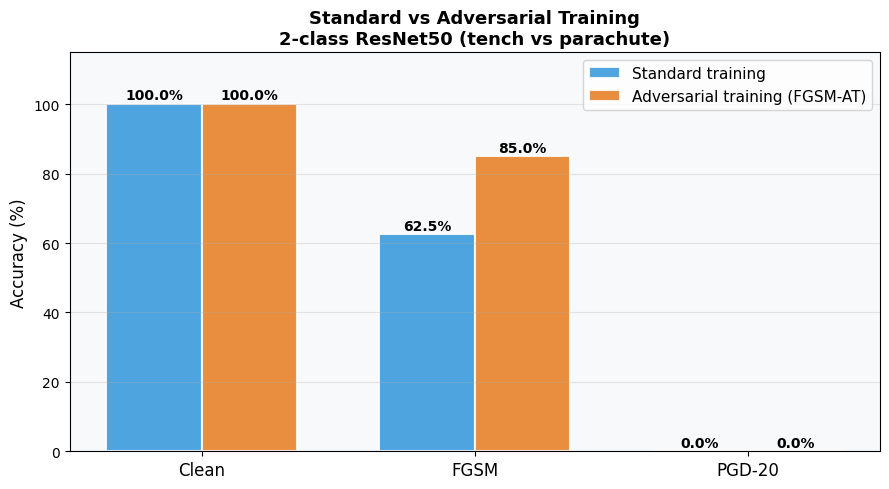

In [10]:
fgsm_2c = lambda img, lbl: fgsm(model_clean, img, lbl, EPS)
pgd_2c  = lambda img, lbl: pgd(model_clean,  img, lbl, EPS)
fgsm_2a = lambda img, lbl: fgsm(model_adv,   img, lbl, EPS)
pgd_2a  = lambda img, lbl: pgd(model_adv,    img, lbl, EPS)

results_clean = {
    'Clean':  eval_2class(model_clean, test_loader_2c),
    'FGSM':   eval_2class(model_clean, test_loader_2c, fgsm_2c),
    'PGD-20': eval_2class(model_clean, test_loader_2c, pgd_2c),
}
results_adv = {
    'Clean':  eval_2class(model_adv, test_loader_2c),
    'FGSM':   eval_2class(model_adv, test_loader_2c, fgsm_2a),
    'PGD-20': eval_2class(model_adv, test_loader_2c, pgd_2a),
}

print('Results -- 2-class (tench vs parachute)')
print(f'{"Condition":20s}  {"Standard":>10s}  {"Adv Trained":>12s}')
print('-' * 46)
for k in ['Clean', 'FGSM', 'PGD-20']:
    print(f'{k:20s}  {results_clean[k]:>10.2%}  {results_adv[k]:>12.2%}')

# ── Grouped bar chart ─────────────────────────────────────────────────────────
labels  = ['Clean', 'FGSM', 'PGD-20']
x       = np.arange(len(labels))
width   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, [results_clean[k]*100 for k in labels],
            width, label='Standard training', color='#3498db', alpha=0.87,
            edgecolor='white', lw=1.5)
b2 = ax.bar(x + width/2, [results_adv[k]*100 for k in labels],
            width, label='Adversarial training (FGSM-AT)', color='#e67e22', alpha=0.87,
            edgecolor='white', lw=1.5)

for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                f'{b.get_height():.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('Standard vs Adversarial Training\n2-class ResNet50 (tench vs parachute)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('adversarial_training.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6: Randomized Smoothing

### The Core Idea

**Randomized smoothing** (Cohen et al., 2019) turns *any* base classifier $f$ into a *certified* smooth classifier $g$:

$$g(x) = \underset{c}{\operatorname{argmax}} \; \mathbb{P}_{\varepsilon \sim \mathcal{N}(0,\sigma^2 I)}\!\left[ f(x + \varepsilon) = c \right]$$

We classify $x$ as whatever class the *noisy* copies of $x$ are most often assigned to by $f$. Because the Gaussian noise is isotropic, the decision is provably stable under L₂ perturbations.

### Certification Theorem (Cohen et al., 2019)

Let $p_A = \max_c \mathbb{P}[f(x+\varepsilon)=c]$. If $p_A > 0.5$, then $g$ is certifiably robust in an L₂ ball of radius:

$$r = \sigma \cdot \Phi^{-1}(p_A)$$

where $\Phi^{-1}$ is the inverse normal CDF (probit function).

- **Larger $\sigma$** → larger certified radius, but noisier predictions → lower clean accuracy.
- **Smaller $\sigma$** → higher clean accuracy, but smaller (or zero) certified radius.

### Why Monte Carlo?

We cannot compute $p_A$ exactly — but we can estimate it with $N$ samples and use a Clopper-Pearson confidence bound. In this notebook we use $N=300$ for speed (production systems use $N=10{,}000$+).

In [11]:
@torch.no_grad()
def smooth_predict(model, image, sigma, N=300, batch_size=50):
    # Monte Carlo smoothed prediction. Returns (predicted_class, vote_fraction_pA).
    counts = torch.zeros(1000, device=device)
    for start in range(0, N, batch_size):
        n     = min(batch_size, N - start)
        noise = torch.randn(n, *image.shape[1:], device=device) * sigma
        noisy = image.expand(n, -1, -1, -1) + noise
        noisy = torch.clamp(noisy,
                            LOWER.expand_as(noisy),
                            UPPER.expand_as(noisy))
        preds = model(noisy).argmax(dim=1)
        for p in preds:
            counts[p] += 1
    cA = counts.argmax().item()
    pA = (counts[cA] / N).item()
    return cA, pA

def certified_radius(pA, sigma):
    # L2 certified radius. Returns 0.0 if pA <= 0.5 (abstain).
    return float(sigma * scipy_norm.ppf(pA)) if pA > 0.5 else 0.0

# ── Demo on panda ──────────────────────────────────────────────────────────────
print(f'{"sigma":>6}  {"Predicted class":25s}  {"pA":>6}  {"Radius":>8}  {"Correct?":>8}')
print('-' * 65)
for sigma in [0.12, 0.25, 0.50, 1.00]:
    cA, pA = smooth_predict(model, panda_tensor, sigma=sigma, N=300)
    radius  = certified_radius(pA, sigma)
    correct = 'Y' if cA == panda_idx else 'N'
    label   = idx_to_label.get(cA, str(cA))
    print(f'{sigma:>6.2f}  {label:25s}  {pA:>6.3f}  {radius:>8.4f}  {correct:>8}')

 sigma  Predicted class                pA    Radius  Correct?
-----------------------------------------------------------------
  0.12  giant panda                 1.000       inf         Y
  0.25  giant panda                 1.000       inf         Y
  0.50  giant panda                 1.000       inf         Y
  1.00  giant panda                 1.000       inf         Y


sigma=0.12  acc=74.00%  mean_radius=inf


sigma=0.25  acc=62.00%  mean_radius=inf


sigma=0.50  acc=40.00%  mean_radius=inf


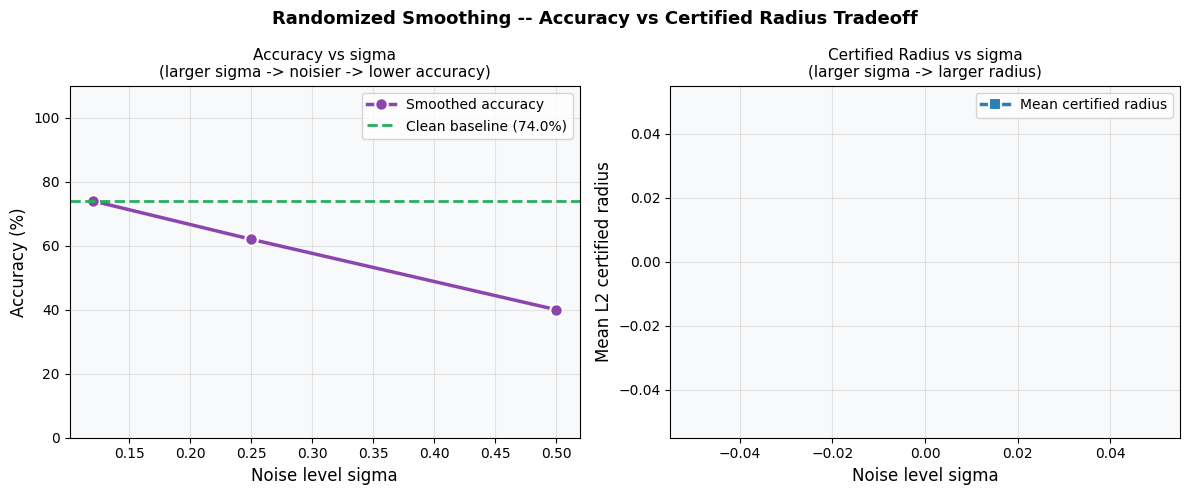

In [12]:
# ── Sweep sigma on the eval set ──────────────────────────────────────────────
sigma_sweep = [0.12, 0.25, 0.50]
N_SMOOTH    = 100   # samples per image -- low for speed, increase for production

sweep_acc    = []
sweep_radius = []

for sigma in sigma_sweep:
    correct = 0; total = 0; radii = []
    for images, labels in tqdm(eval_loader, desc=f'sigma={sigma}', leave=False):
        images, labels = images.to(device), labels.to(device)
        cA, pA = smooth_predict(model, images, sigma=sigma, N=N_SMOOTH)
        r = certified_radius(pA, sigma)
        radii.append(r)
        if cA == labels.item():
            correct += 1
        total += 1
    sweep_acc.append(correct / total)
    sweep_radius.append(np.mean(radii))
    print(f'sigma={sigma:.2f}  acc={correct/total:.2%}  mean_radius={np.mean(radii):.4f}')

# ── Two-panel plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Randomized Smoothing -- Accuracy vs Certified Radius Tradeoff',
             fontsize=13, fontweight='bold')

ax1.plot(sigma_sweep, [a*100 for a in sweep_acc],
         'o-', color='#8e44ad', lw=2.5, ms=9, markeredgecolor='white', markeredgewidth=1.5,
         label='Smoothed accuracy')
ax1.axhline(acc_clean * 100, color='#27ae60', ls='--', lw=2,
            label=f'Clean baseline ({acc_clean:.1%})')
ax1.set_xlabel('Noise level sigma', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy vs sigma\n(larger sigma -> noisier -> lower accuracy)', fontsize=11)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3); ax1.set_facecolor('#f8f9fa')
ax1.set_ylim(0, 110)

ax2.plot(sigma_sweep, sweep_radius,
         's-', color='#2980b9', lw=2.5, ms=9, markeredgecolor='white', markeredgewidth=1.5,
         label='Mean certified radius')
ax2.set_xlabel('Noise level sigma', fontsize=12)
ax2.set_ylabel('Mean L2 certified radius', fontsize=12)
ax2.set_title('Certified Radius vs sigma\n(larger sigma -> larger radius)', fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3); ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('randomized_smoothing.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 7: Why Certifying L₂ is Harder Than L∞

### Geometry: Two Very Different Threat Models

| Property | L∞ Ball | L₂ Ball |
|----------|---------|---------|
| Shape | Axis-aligned hypercube | Hypersphere |
| Vertices (d-dim) | $2^d$ — exponentially many | None (smooth boundary) |
| Tight linear relaxation | Yes — easy to propagate | No — becomes an ellipsoid |
| Natural attack | FGSM, PGD | C&W, DeepFool |

### Interval Bound Propagation (IBP) — Why It Works for L∞

For an L∞ perturbation, each input pixel $x_i$ lives in a 1D interval $[x_i - \epsilon, x_i + \epsilon]$.

**IBP** propagates these intervals layer by layer through the network:

1. **Linear layer** $W$: if input is in $[\mathbf{l}, \mathbf{u}]$, output is in $[W^+\mathbf{l} - W^-\mathbf{u},\ W^+\mathbf{u} - W^-\mathbf{l}]$ (where $W^\pm$ are the positive/negative parts of $W$). This is **tight**.
2. **ReLU**: $[\text{ReLU}(l_i),\ \text{ReLU}(u_i)]$ — also **tight**.
3. **Composition**: chain the above — IBP gives an **exact** certified bound.

### Why IBP Fails for L₂

An L₂ ball in input space maps through a linear layer $W$ to an **ellipsoid** in output space:

$$\{Wz : \|z\|_2 \le r\} = \text{ellipsoid with axes } \sigma_i(W) \cdot r$$

To apply IBP we would have to bound this ellipsoid by an axis-aligned box. The box is a **very loose over-approximation** — it certifies a far smaller radius than the ellipsoid actually covers, or requires an expensive semidefinite program (SDP) to tighten it.

**Randomized smoothing** sidesteps this by using a probabilistic argument (the Gaussian measure of a halfspace) rather than trying to propagate geometry through layers.

### Comparison Table

| Method | Guarantee type | Scalability | Accuracy degradation | Key paper |
|--------|----------------|-------------|---------------------|-----------|
| IBP Certified Training | Deterministic L∞ | Good (same as training) | High | Gowal et al., 2018 |
| Randomized Smoothing | Probabilistic L₂ | Good (N×inference) | Medium | Cohen et al., 2019 |
| SDP-based verification | Deterministic L₂/L∞ | Poor ($O(n^3)$) | Low | Raghunathan et al., 2018 |
| CROWN / α-CROWN | Deterministic L∞ | Good (GPU-parallel) | Medium | Zhang et al., 2018 |

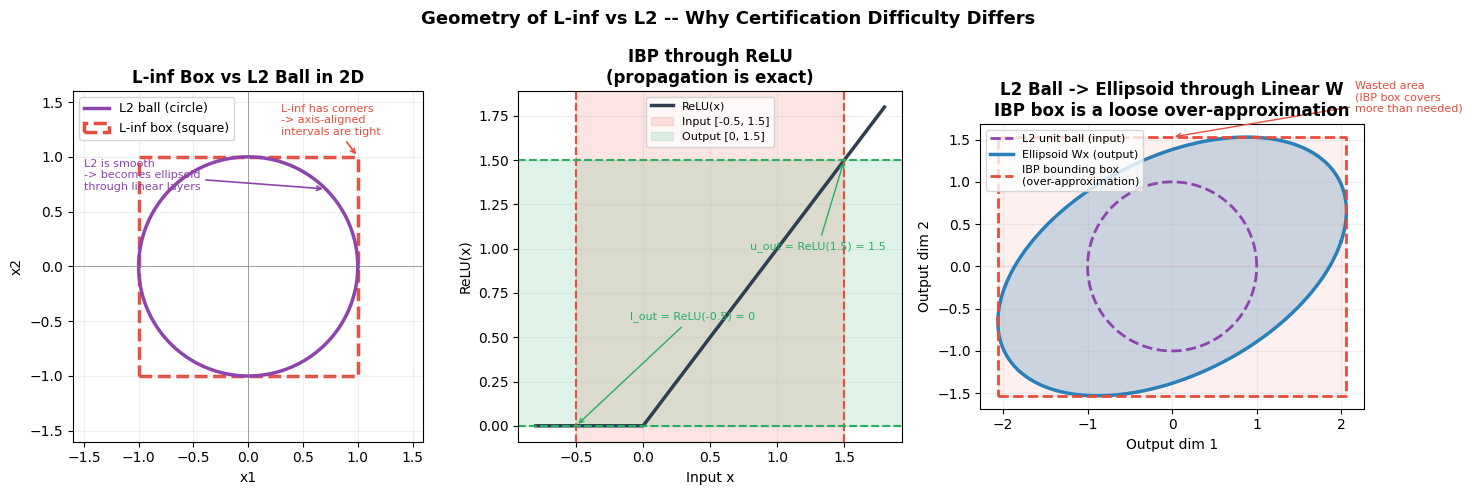

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Geometry of L-inf vs L2 -- Why Certification Difficulty Differs',
             fontsize=13, fontweight='bold')

# ── Panel 1: L-inf box vs L2 circle ──────────────────────────────────────────
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 300)
r = 1.0
ax.plot(r*np.cos(theta), r*np.sin(theta),
        color='#8e44ad', lw=2.5, label='L2 ball (circle)')
square = plt.Polygon([[-r,-r],[r,-r],[r,r],[-r,r]],
                     fill=False, edgecolor='#e74c3c', lw=2.5,
                     linestyle='--', label='L-inf box (square)')
ax.add_patch(square)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title('L-inf Box vs L2 Ball in 2D', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.annotate('L-inf has corners\n-> axis-aligned\nintervals are tight',
            xy=(r, r), xytext=(0.3, 1.2),
            fontsize=8, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))
ax.annotate('L2 is smooth\n-> becomes ellipsoid\nthrough linear layers',
            xy=(r*np.cos(np.pi/4), r*np.sin(np.pi/4)),
            xytext=(-1.5, 0.7),
            fontsize=8, color='#8e44ad',
            arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.2))

# ── Panel 2: IBP through ReLU ─────────────────────────────────────────────────
ax = axes[1]
l_in, u_in = -0.5, 1.5
x_in = np.linspace(l_in - 0.3, u_in + 0.3, 300)
relu_out = np.maximum(0, x_in)
l_out = max(0, l_in); u_out = max(0, u_in)

ax.plot(x_in, relu_out, color='#2c3e50', lw=2.5, label='ReLU(x)')
ax.axvspan(l_in, u_in, alpha=0.15, color='#e74c3c', label=f'Input [{l_in}, {u_in}]')
ax.axhspan(l_out, u_out, alpha=0.15, color='#27ae60', label=f'Output [{l_out}, {u_out}]')
ax.axvline(l_in, color='#e74c3c', ls='--', lw=1.5)
ax.axvline(u_in, color='#e74c3c', ls='--', lw=1.5)
ax.axhline(l_out, color='#27ae60', ls='--', lw=1.5)
ax.axhline(u_out, color='#27ae60', ls='--', lw=1.5)
ax.annotate(f'l_out = ReLU({l_in}) = {l_out}',
            xy=(l_in, l_out), xytext=(-0.1, 0.6),
            fontsize=8, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))
ax.annotate(f'u_out = ReLU({u_in}) = {u_out}',
            xy=(u_in, u_out), xytext=(0.8, 1.0),
            fontsize=8, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))
ax.set_xlabel('Input x'); ax.set_ylabel('ReLU(x)')
ax.set_title('IBP through ReLU\n(propagation is exact)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# ── Panel 3: L2 ball -> ellipsoid through linear layer ────────────────────────
ax = axes[2]
W = np.array([[2.0, 0.5], [0.3, 1.5]])

theta2 = np.linspace(0, 2*np.pi, 300)
circle = np.stack([np.cos(theta2), np.sin(theta2)], axis=0)
ellipse = W @ circle

el_min = ellipse.min(axis=1)
el_max = ellipse.max(axis=1)

ax.plot(circle[0], circle[1], color='#8e44ad', lw=2, label='L2 unit ball (input)', ls='--')
ax.fill(ellipse[0], ellipse[1], alpha=0.25, color='#2980b9')
ax.plot(ellipse[0], ellipse[1], color='#2980b9', lw=2.5, label='Ellipsoid Wx (output)')

box_x = [el_min[0], el_max[0], el_max[0], el_min[0], el_min[0]]
box_y = [el_min[1], el_min[1], el_max[1], el_max[1], el_min[1]]
ax.plot(box_x, box_y, color='#e74c3c', lw=2, ls='--',
        label='IBP bounding box\n(over-approximation)')
ax.fill_between(box_x, box_y, alpha=0.08, color='#e74c3c')

ax.set_aspect('equal')
ax.set_title('L2 Ball -> Ellipsoid through Linear W\nIBP box is a loose over-approximation',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.2)
ax.set_xlabel('Output dim 1'); ax.set_ylabel('Output dim 2')
ax.annotate('Wasted area\n(IBP box covers\nmore than needed)',
            xy=((el_min[0]+el_max[0])/2, el_max[1]),
            xytext=(el_max[0]+0.1, el_max[1]+0.3),
            fontsize=8, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

plt.tight_layout()
plt.savefig('l2_vs_linf_geometry.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8: Defense Comparison Summary

### All Defenses at a Glance

| Defense | Type | Threat model | Certification | Clean acc cost | Training cost |
|---------|------|-------------|---------------|----------------|---------------|
| JPEG (q=75) | Preprocessing | L∞/L₂ (heuristic) | None | Very low | None |
| Gaussian (σ=1) | Preprocessing | L∞/L₂ (heuristic) | None | Low | None |
| BitDepth (5b) | Preprocessing | L∞/L₂ (heuristic) | None | Very low | None |
| Adv Training (FGSM-AT) | Empirical | L∞ | None | Medium | High |
| Randomized Smoothing | Certified | L₂ | Probabilistic | Medium–High | Low |
| IBP Certified Training | Certified | L∞ | Deterministic | High | Very High |

### Key Observations

1. **No free lunch**: Every defense trades clean accuracy for robustness. Certified defenses pay a larger accuracy tax.
2. **Preprocessing is fragile**: An adaptive attacker who knows the defense can route around it entirely. Never rely on preprocessing alone.
3. **Adversarial training is the empirical gold standard**: PGD-AT remains competitive on benchmarks, but it is only as strong as the attack used at training time.
4. **Certification is norm-specific**: A defense certified for L∞ (IBP) provides no guarantee against L₂ attacks (C&W) and vice versa. Always match the certification to the threat model.

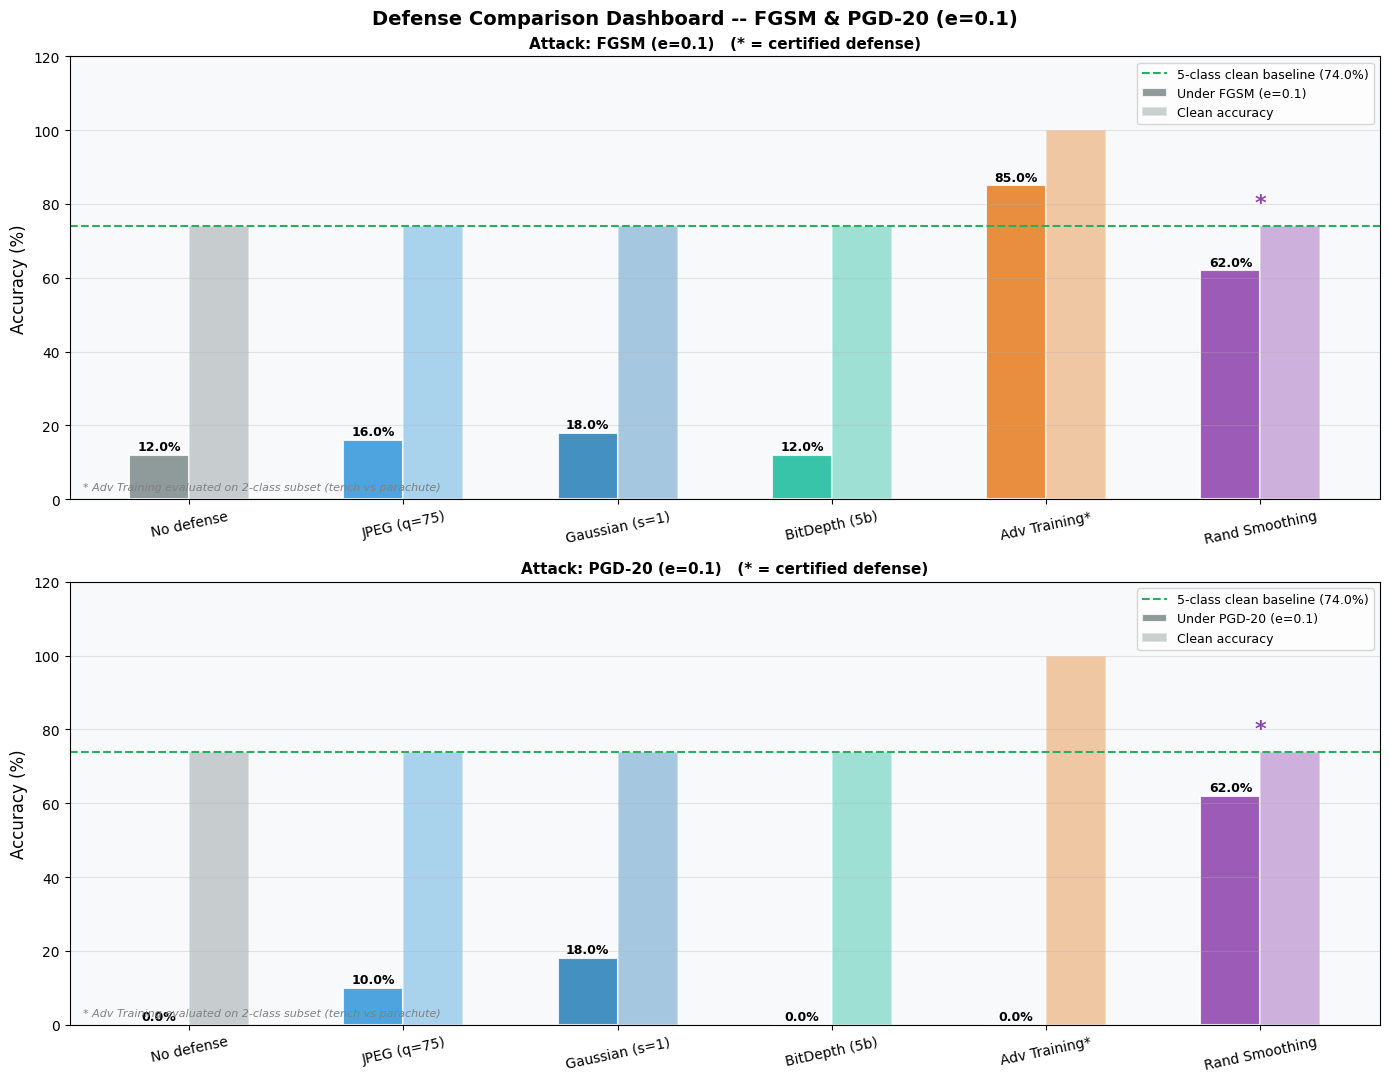

In [14]:
# ── Unified results for 5-class defenses ─────────────────────────────────────
# Note: adversarial training results are 2-class; all others are 5-class.
fgsm_results = {
    'No defense':           acc_fgsm,
    'JPEG (q=75)':          prep_results['FGSM']['JPEG (q=75)'],
    'Gaussian (s=1)':       prep_results['FGSM']['Gaussian (s=1)'],
    'BitDepth (5b)':        prep_results['FGSM']['BitDepth (5b)'],
    'Adv Training*':        results_adv['FGSM'],
    'Rand Smoothing':       sweep_acc[1],
}
pgd_results = {
    'No defense':           acc_pgd,
    'JPEG (q=75)':          prep_results['PGD-20']['JPEG (q=75)'],
    'Gaussian (s=1)':       prep_results['PGD-20']['Gaussian (s=1)'],
    'BitDepth (5b)':        prep_results['PGD-20']['BitDepth (5b)'],
    'Adv Training*':        results_adv['PGD-20'],
    'Rand Smoothing':       sweep_acc[1],
}
clean_results_5c = {
    'No defense':           acc_clean,
    'JPEG (q=75)':          acc_clean,
    'Gaussian (s=1)':       acc_clean,
    'BitDepth (5b)':        acc_clean,
    'Adv Training*':        results_adv['Clean'],
    'Rand Smoothing':       sweep_acc[0],
}

def_names  = list(fgsm_results.keys())
certified  = {'Rand Smoothing'}
bar_colors_map = {
    'No defense':       '#7f8c8d',
    'JPEG (q=75)':      '#3498db',
    'Gaussian (s=1)':   '#2980b9',
    'BitDepth (5b)':    '#1abc9c',
    'Adv Training*':    '#e67e22',
    'Rand Smoothing':   '#8e44ad',
}
colors = [bar_colors_map[d] for d in def_names]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('Defense Comparison Dashboard -- FGSM & PGD-20 (e=0.1)',
             fontsize=14, fontweight='bold')

x     = np.arange(len(def_names))
width = 0.28

for ax, atk_label, atk_res in [
        (ax1, 'FGSM (e=0.1)', fgsm_results),
        (ax2, 'PGD-20 (e=0.1)', pgd_results)]:
    atk_vals   = [atk_res[d]*100   for d in def_names]
    clean_vals = [clean_results_5c[d]*100 for d in def_names]

    b_atk   = ax.bar(x - width/2, atk_vals,   width, color=colors, alpha=0.87,
                     edgecolor='white', lw=1.5, label=f'Under {atk_label}')
    b_clean = ax.bar(x + width/2, clean_vals, width, color=colors, alpha=0.4,
                     edgecolor='white', lw=1.5, label='Clean accuracy')

    for b, v in zip(b_atk, atk_vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Mark certified defenses with a star
    for i, d in enumerate(def_names):
        if d in certified:
            ax.text(i, max(atk_vals[i], clean_vals[i]) + 4.5, '*',
                    ha='center', fontsize=16, color='#8e44ad', fontweight='bold')

    ax.axhline(acc_clean*100, color='#27ae60', ls='--', lw=1.5,
               label=f'5-class clean baseline ({acc_clean:.1%})')
    ax.set_xticks(x)
    ax.set_xticklabels(def_names, rotation=12, fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_ylim(0, 120)
    ax.set_title(f'Attack: {atk_label}   (* = certified defense)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, axis='y', alpha=0.3); ax.set_facecolor('#f8f9fa')
    ax.text(0.01, 0.02, '* Adv Training evaluated on 2-class subset (tench vs parachute)',
            transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('defense_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 9: Conclusion

### What We Learned

| Question | Answer |
|----------|--------|
| Can preprocessing reliably defend against adversarial examples? | **No** — adaptive attackers bypass it easily |
| Does adversarial training offer guarantees? | **No** — but it gives the best empirical robustness |
| What does randomized smoothing certify? | **L₂ ball** — probabilistic guarantee with $N$ forward passes |
| What does IBP certify? | **L∞ ball** — deterministic, but large accuracy cost |
| Why is L₂ harder to certify deterministically? | L₂ balls become **ellipsoids** through linear layers — IBP is loose |

### The Robustness Ladder

```
Strongest guarantees
        ^
        |   IBP Certified Training -- deterministic L-inf, but high accuracy cost
        |
        |   Randomized Smoothing   -- probabilistic L2, scalable
        |
        |   Adversarial Training   -- no guarantee, but best empirical robustness
        |
        |   Input Preprocessing    -- heuristic, easily bypassed by adaptive attacks
        |
        v
Weakest / no guarantees
```

### 5 Practical Recommendations

1. **Use adversarial training as your first empirical defense** — start with FGSM-AT, upgrade to PGD-AT when you have the compute budget.
2. **Never trust preprocessing as a sole defense** — always evaluate against an *adaptive* attacker that knows your defense.
3. **Match the certification to the threat model** — randomized smoothing for L₂ threats (C&W), IBP/CROWN for L∞ (FGSM/PGD).
4. **Report both clean and robust accuracy** — a defense that achieves 0% clean accuracy is technically robust to everything.
5. **Check RobustBench** (https://robustbench.github.io/) for state-of-the-art certified and empirical defenses on standard benchmarks.

### What's Next — Part 4: Attacks on LLMs

The adversarial landscape shifts completely when the model is a **large language model**:
- The input space is now *discrete tokens*, not continuous pixel values.
- Gradient-based attacks must be adapted (AutoDAN, GCG suffix attacks).
- The threat model expands: **prompt injection**, **jailbreaking**, **indirect injection via RAG**.

Part 4 will run entirely in a **Docker environment** with a local LLM — no cloud API needed.

---

### References

1. Goodfellow et al. (2014). *Explaining and Harnessing Adversarial Examples*. ICLR 2015. [arXiv:1412.6572](https://arxiv.org/abs/1412.6572)
2. Madry et al. (2017). *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR 2018. [arXiv:1706.06083](https://arxiv.org/abs/1706.06083)
3. Cohen et al. (2019). *Certified Adversarial Robustness via Randomized Smoothing*. ICML 2019. [arXiv:1902.02918](https://arxiv.org/abs/1902.02918)
4. Gowal et al. (2018). *On the Effectiveness of Interval Bound Propagation for Training Verifiably Robust Models*. [arXiv:1810.12715](https://arxiv.org/abs/1810.12715)
5. Carlini & Wagner (2017). *Towards Evaluating the Robustness of Neural Networks*. IEEE S&P 2017. [arXiv:1608.04644](https://arxiv.org/abs/1608.04644)
6. Croce & Hein (2020). *Reliable evaluation of adversarial robustness with an ensemble of diverse parameter-free attacks*. ICML 2020. [arXiv:2003.01690](https://arxiv.org/abs/2003.01690)